In [71]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

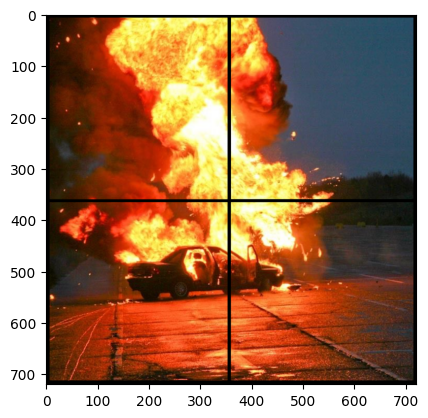

In [72]:
citra = plt.imread('Assets/Meledak.png')
plt.imshow(citra)

In [ ]:
def pastikan_uint8(citra):
    """
    Mengubah citra ke format uint8 rentang 0-255.

    Kenapa perlu?
    - Beberapa fungsi membaca gambar sebagai float 0-1.
    - Fungsi histogram manual lebih aman jika nilai piksel berupa integer 0-255.
    """
    citra = np.array(citra)

    if citra.dtype == np.uint8:
        return citra

    if citra.max() <= 1.0:
        citra = citra * 255

    return np.clip(citra, 0, 255).astype(np.uint8)
def hitung_cdf(citra):
    """
    Menghitung CDF dari citra grayscale.

    Return:
    - hist: histogram jumlah piksel
    - cdf: cumulative distribution function
    """
    hist = buat_hist(citra, normalisasi=False)
    cdf = np.zeros(256, dtype=float)

    cdf[0] = hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i - 1] + hist[i]

    return hist, cdf

def baca_grayscale(path):
    """
    Membaca citra dari path dan mengubahnya menjadi grayscale.

    Parameter:
    - path: lokasi file gambar, contoh: "Assets/soal1.png"

    Return:
    - citra grayscale bertipe uint8
    """
    citra = cv.imread(path, cv.IMREAD_GRAYSCALE)

    if citra is None:
        raise FileNotFoundError(f"Gambar tidak ditemukan: {path}")

    return pastikan_uint8(citra)


def baca_rgb(path):
    """
    Membaca citra berwarna dan mengubah format BGR OpenCV menjadi RGB Matplotlib.
    """
    citra_bgr = cv.imread(path, cv.IMREAD_COLOR)

    if citra_bgr is None:
        raise FileNotFoundError(f"Gambar tidak ditemukan: {path}")

    citra_rgb = cv.cvtColor(citra_bgr, cv.COLOR_BGR2RGB)
    return pastikan_uint8(citra_rgb)


def buat_hist(citra, normalisasi=False):
    """
    Membuat histogram manual untuk citra grayscale.

    Parameter:
    - citra: citra grayscale 2D
    - normalisasi:
      False -> histogram berisi jumlah piksel
      True  -> histogram berisi proporsi piksel

    Return:
    - histogram array panjang 256
    """
    citra = pastikan_uint8(citra)

    if len(citra.shape) != 2:
        raise ValueError("buat_hist hanya menerima citra grayscale 2D.")

    tinggi, lebar = citra.shape
    hist = np.zeros(256, dtype=float)

    for i in range(tinggi):
        for j in range(lebar):
            nilai = int(citra[i, j])
            hist[nilai] += 1

    if normalisasi:
        total_piksel = tinggi * lebar
        hist = hist / total_piksel

    return hist

def tampilkan_citra(citra, judul="Citra", cmap="gray", figsize=(8, 5)):
    """
    Menampilkan satu citra.
    """
    plt.figure(figsize=figsize)

    if len(citra.shape) == 2:
        plt.imshow(citra, cmap=cmap)
    else:
        plt.imshow(citra)

    plt.title(judul)
    plt.axis("off")
    plt.show()

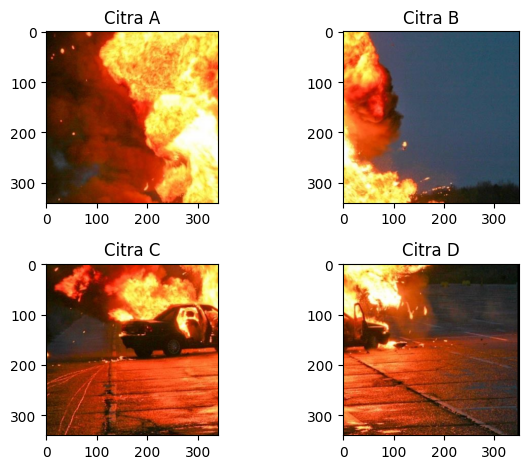

In [74]:
def slice(gambar, a, b, mode='H'): 
    return gambar[a:b, :] if mode == 'H' else gambar[:, a:b]

citra1 = slice(citra, 10, 350, mode='H')
HasilCitA = slice(citra1, 10, 350, mode='V')

citra2 = slice(citra, 10, 350, mode='H')
HasilCitB = slice(citra2, 360, 710, mode='V')

citra3 = slice(citra, 370, 710, mode='H')
HasilCitC = slice(citra3, 10, 350, mode='V')

citra4 = slice(citra, 370, 710, mode='H')
HasilCitD = slice(citra4, 370, 720, mode='V')

plt.subplot (2,2,1) 
plt.imshow(HasilCitA)
plt.title('Citra A')    

plt.subplot (2,2,2)
plt.imshow(HasilCitB)
plt.title('Citra B')

plt.subplot (2,2,3)
plt.imshow(HasilCitC)
plt.title('Citra C')

plt.subplot (2,2,4)
plt.imshow(HasilCitD)
plt.title('Citra D')

plt.tight_layout()

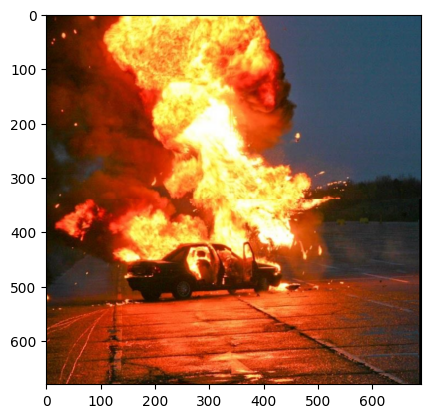

In [75]:
def merge(ci1, ci2, orientation='H'): 
    if orientation == 'H':   
        tinggi = max(ci1.shape[0], ci2.shape[0]) 
        lebar_total = ci1.shape[1] + ci2.shape[1] 
    
        if len(ci1.shape) == 2: 
            gabungan = np.zeros((tinggi, lebar_total), dtype=ci1.dtype) 
        else: 
            gabungan = np.zeros((tinggi, lebar_total, ci1.shape[2]), dtype=ci1.dtype) 
         
        gabungan[0:ci1.shape[0], 0:ci1.shape[1]] = ci1 
        gabungan[0:ci2.shape[0], ci1.shape[1]:ci1.shape[1]+ci2.shape[1]] = ci2   
    else:   
        tinggi_total = ci1.shape[0] + ci2.shape[0] 
        lebar = max(ci1.shape[1], ci2.shape[1]) 
         
        if len(ci1.shape) == 2: 
            gabungan = np.zeros((tinggi_total, lebar), dtype=ci1.dtype) 
        else: 
            gabungan = np.zeros((tinggi_total, lebar, ci1.shape[2]), dtype=ci1.dtype) 
         
        gabungan[0:ci1.shape[0], 0:ci1.shape[1]] = ci1 
        gabungan[ci1.shape[0]:ci1.shape[0]+ci2.shape[0], 0:ci2.shape[1]] = ci2 
     
    return gabungan

GabungAtas = merge(HasilCitA, HasilCitB, "H")
GabungBawah = merge(HasilCitC, HasilCitD, "H")
GabungAtasBawah = merge(GabungAtas, GabungBawah, "V")

plt.imshow(GabungAtasBawah)


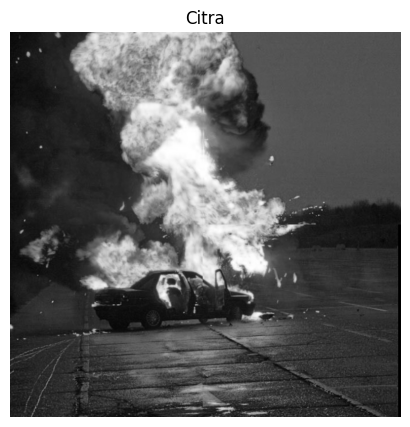

In [76]:
citraGray = cv.cvtColor(GabungAtasBawah,cv.COLOR_BGR2GRAY)
tampilkan_citra(citraGray)

In [78]:
def ekualisasi(citra):
    """
    Melakukan ekualisasi histogram secara manual.

    Parameter:
    - citra: citra grayscale 2D

    Return:
    - hasil: citra hasil ekualisasi
    """
    citra = pastikan_uint8(citra)

    if len(citra.shape) != 2:
        raise ValueError("ekualisasi hanya menerima citra grayscale 2D.")

    tinggi, lebar = citra.shape
    total_piksel = tinggi * lebar

    hist, cdf = hitung_cdf(citra)

    cdf_normal = np.round((cdf * 255) / total_piksel).astype(np.uint8)

    hasil = np.zeros_like(citra, dtype=np.uint8)

    for i in range(tinggi):
        for j in range(lebar):
            nilai_lama = citra[i, j]
            hasil[i, j] = cdf_normal[nilai_lama]

    return hasil

HasilEkualisasi = ekualisasi(citraGray)
tampilkan_citra(HasilEkualisasi, "Setelah Ekualisasi")

NameError: name 'buat_hist' is not defined

In [ ]:
def bandingkan_histogram(citra1, citra2, judul1="Sebelum", judul2="Sesudah"):
    """
    Membandingkan histogram dua citra.
    Cocok untuk melihat efek ekualisasi atau spesifikasi.
    """
    hist1 = bandingkan_histogram(citra1)
    hist2 = bandingkan_histogram(citra2)

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 2, 1)
    plt.bar(range(256), hist1, color="gray", width=0.8)
    plt.title(judul1)
    plt.xlabel("Intensitas Piksel")
    plt.ylabel("Jumlah Piksel")
    plt.xlim([0, 255])

    plt.subplot(1, 2, 2)
    plt.bar(range(256), hist2, color="gray", width=0.8)
    plt.title(judul2)
    plt.xlabel("Intensitas Piksel")
    plt.ylabel("Jumlah Piksel")
    plt.xlim([0, 255])

    plt.tight_layout()
    plt.show()

In [ ]:
bandingkan_histogram(citra, citraGray, "Histogram Sebelum dan Sesudah Ekualisasi")

TypeError: bandingkan_histogram() missing 1 required positional argument: 'citra2'